In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import joblib


In [11]:
df = pd.read_csv("/content/drive/MyDrive/iomt_multiclass_attack_dataset.csv")

print(df.head())
print(df.info())


   flow_duration_ms  packet_rate     byte_rate  avg_packet_size  \
0       3149.014246    48.617357  21943.065614       460.921194   
1       3035.398384    64.623781  24616.144903       302.435767   
2       2842.463145    69.127713  13919.841153       444.776944   
3       2633.746905    53.229998  15819.749177       312.866630   
4       3232.110125    44.618583  15959.965708       364.776349   

   packet_size_variance  inter_arrival_time_mean  inter_arrival_time_std  \
0            953.169325                19.297589                5.579213   
1           1120.688245                19.246868                3.836133   
2           1155.838527                16.696707                5.130228   
3            791.220718                20.518081                4.324199   
4            773.889539                20.403287                4.582123   

   payload_entropy  tcp_flag_count  retransmission_rate  flow_direction_ratio  \
0         3.306974               5             0.001692    

In [12]:
# Check missing values
print(df.isnull().sum())

# Split features and target
X = df.drop("label", axis=1)
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


flow_duration_ms           0
packet_rate                0
byte_rate                  0
avg_packet_size            0
packet_size_variance       0
inter_arrival_time_mean    0
inter_arrival_time_std     0
payload_entropy            0
tcp_flag_count             0
retransmission_rate        0
flow_direction_ratio       0
connection_reset_count     0
session_request_rate       0
device_type                0
label                      0
dtype: int64


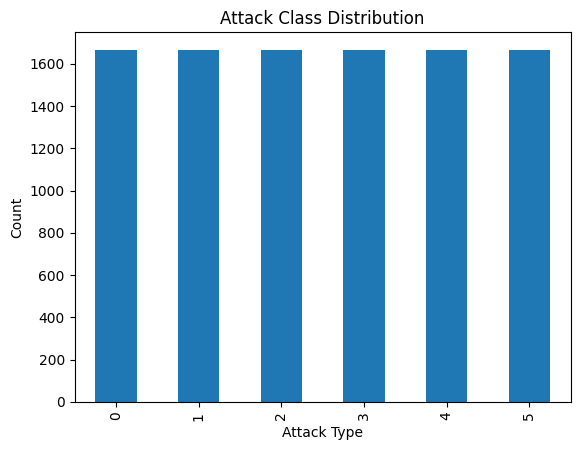

In [13]:
df["label"].value_counts().plot(kind="bar")
plt.title("Attack Class Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()


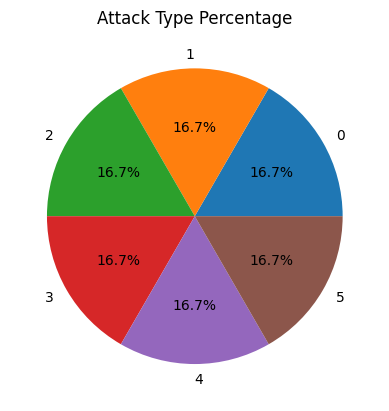

In [14]:
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Attack Type Percentage")
plt.ylabel("")
plt.show()


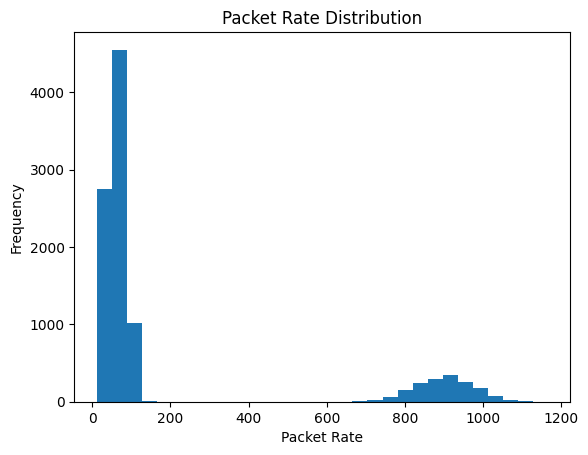

In [15]:
plt.hist(df["packet_rate"], bins=30)
plt.title("Packet Rate Distribution")
plt.xlabel("Packet Rate")
plt.ylabel("Frequency")
plt.show()


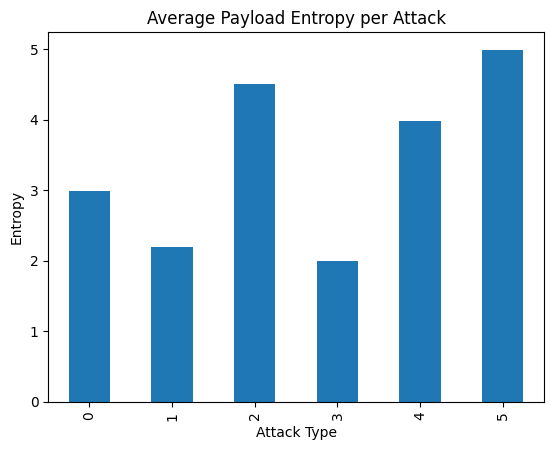

In [16]:
df.groupby("label")["payload_entropy"].mean().plot(kind="bar")
plt.title("Average Payload Entropy per Attack")
plt.xlabel("Attack Type")
plt.ylabel("Entropy")
plt.show()


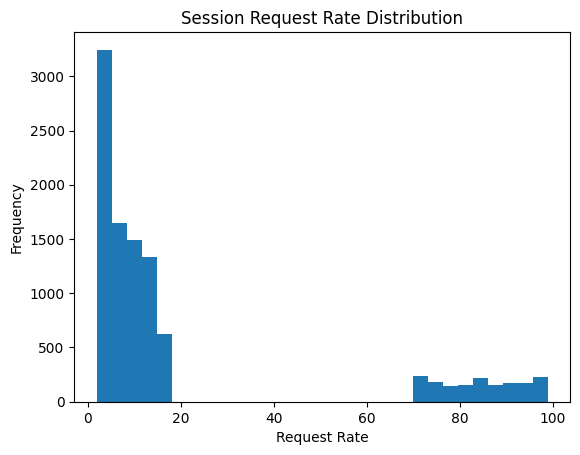

In [17]:
plt.hist(df["session_request_rate"], bins=30)
plt.title("Session Request Rate Distribution")
plt.xlabel("Request Rate")
plt.ylabel("Frequency")
plt.show()


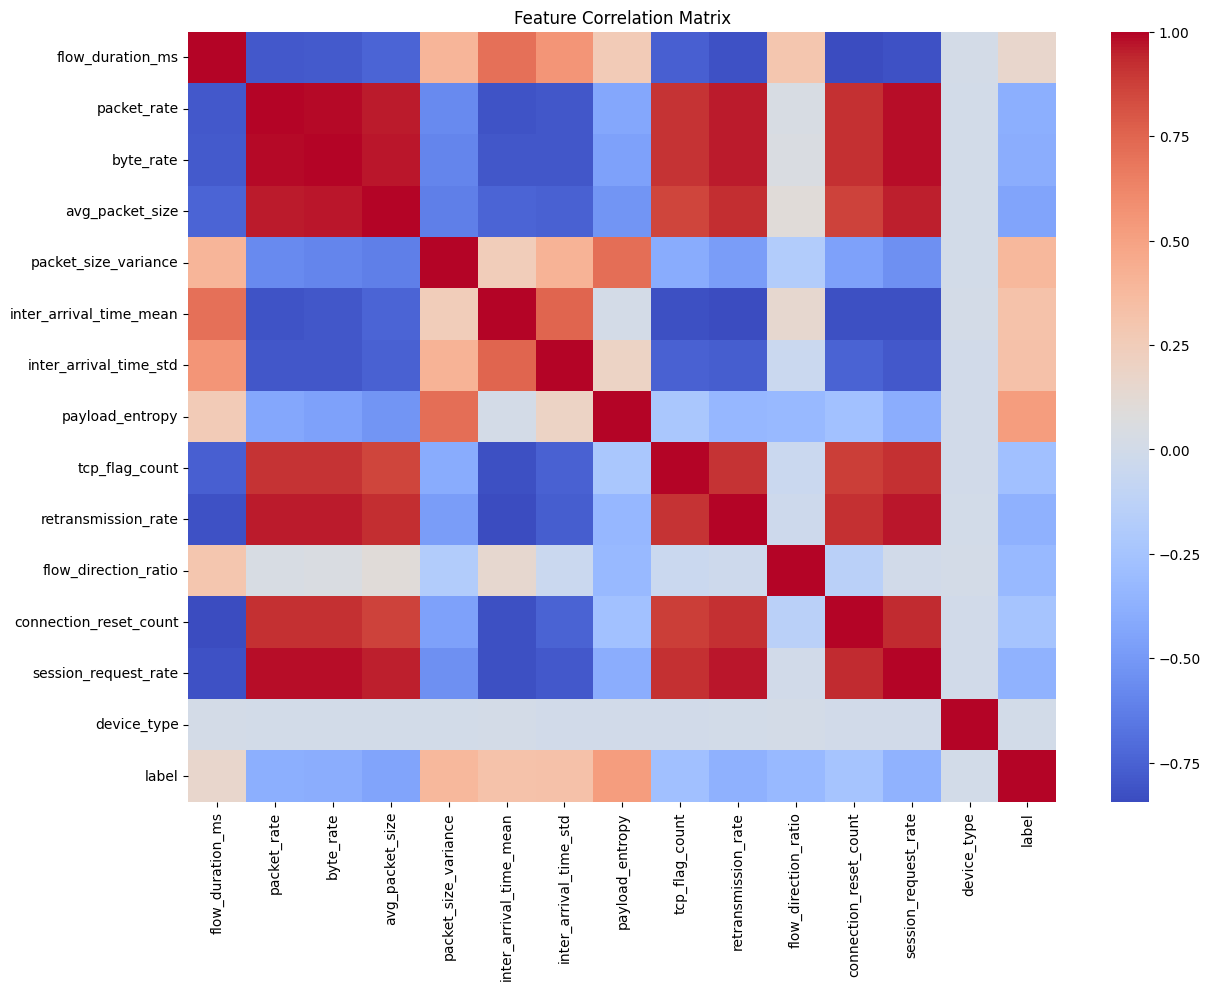

In [18]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=150),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf", probability=True)
}


In [20]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("="*50)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.9890
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       333
           1       1.00      1.00      1.00       333
           2       0.98      0.98      0.98       333
           3       0.99      0.99      0.99       334
           4       0.98      0.98      0.98       334
           5       0.99      0.99      0.99       333

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

Model: Random Forest
Accuracy: 0.9975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      0.99      0.99       333
           3       1.00      1.00      1.00       334
           4       0.99      1.00      0.99       334
           5       1.00      1.00      1.00       

In [21]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

joblib.dump(best_model, "best_iomt_attack_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Best Model:", best_model_name)
print("Model saved successfully!")


Best Model: Random Forest
Model saved successfully!


In [22]:
model = joblib.load("best_iomt_attack_model.pkl")
scaler = joblib.load("scaler.pkl")


In [23]:
attack_map = {
    0: "Normal",
    1: "DoS",
    2: "MITM",
    3: "Replay",
    4: "Spoofing",
    5: "Data Falsification"
}

def predict_attack(input_dict):
    df_input = pd.DataFrame([input_dict])
    df_scaled = scaler.transform(df_input)
    prediction = model.predict(df_scaled)[0]
    return attack_map[prediction]


In [24]:
sample1 = {
    "flow_duration_ms": 3100,
    "packet_rate": 52,
    "byte_rate": 21000,
    "avg_packet_size": 390,
    "packet_size_variance": 980,
    "inter_arrival_time_mean": 21,
    "inter_arrival_time_std": 4,
    "payload_entropy": 3.1,
    "tcp_flag_count": 6,
    "retransmission_rate": 0.01,
    "flow_direction_ratio": 1.2,
    "connection_reset_count": 0,
    "session_request_rate": 5,
    "device_type": 2
}
print(predict_attack(sample1))


Normal


In [25]:
sample2 = {
    "flow_duration_ms": 700,
    "packet_rate": 920,
    "byte_rate": 880000,
    "avg_packet_size": 1010,
    "packet_size_variance": 620,
    "inter_arrival_time_mean": 1.3,
    "inter_arrival_time_std": 0.6,
    "payload_entropy": 2.1,
    "tcp_flag_count": 16,
    "retransmission_rate": 0.4,
    "flow_direction_ratio": 1.0,
    "connection_reset_count": 15,
    "session_request_rate": 90,
    "device_type": 1
}
print(predict_attack(sample2))


DoS


In [26]:
sample3 = {
    "flow_duration_ms": 2100,
    "packet_rate": 95,
    "byte_rate": 36000,
    "avg_packet_size": 370,
    "packet_size_variance": 1500,
    "inter_arrival_time_mean": 14,
    "inter_arrival_time_std": 5,
    "payload_entropy": 4.6,
    "tcp_flag_count": 8,
    "retransmission_rate": 0.1,
    "flow_direction_ratio": 0.7,
    "connection_reset_count": 4,
    "session_request_rate": 14,
    "device_type": 3
}
print(predict_attack(sample3))


MITM


In [27]:
sample4 = {
    "flow_duration_ms": 2800,
    "packet_rate": 62,
    "byte_rate": 22000,
    "avg_packet_size": 360,
    "packet_size_variance": 1400,
    "inter_arrival_time_mean": 19,
    "inter_arrival_time_std": 4,
    "payload_entropy": 5.2,
    "tcp_flag_count": 7,
    "retransmission_rate": 0.03,
    "flow_direction_ratio": 1.0,
    "connection_reset_count": 2,
    "session_request_rate": 7,
    "device_type": 2
}
print(predict_attack(sample4))


Data Falsification
